<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.975 · Deep Learning · PAC2</p>
<p style="margin: 0; text-align:right;">2024-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PAC 2: Xarxes neuronals recurrents amb Keras

<u>Consideracions generals</u>:

- Aquesta PAC s'ha de realitzar de forma **estrictament individual**. Qualsevol indicatiu de còpia serà penalitzat amb un suspens (D) per a totes les parts implicades i la possible avaluació negativa de l'assignatura de manera íntegra.
- És necessari que l'estudiant indiqui **totes les fonts** que ha utilitzat per a la realització de la PAC. De no ser així, es considerarà que l'estudiant ha comès plagi, sent penalitzat amb un suspens (D) i la possible avaluació negativa de l'assignatura de manera íntegra.

<u>Format de l'entrega</u>:

- Alguns exercicis poden suposar diversos minuts d'execució, per la qual cosa l'entrega s'ha de fer en **format notebook** i en **format html**, on es vegi el codi, els resultats i comentaris de cada exercici. Es pot exportar el notebook a HTML des del menú File $\to$ Download as $\to$ HTML.
- Existeix un tipus de cel·la especial per allotjar text. Aquest tipus de cel·la us serà molt útil per respondre a les diferents preguntes teòriques plantejades al llarg de l'activitat. Per canviar el tipus de cel·la a aquest tipus, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

Nota: La majora d'exercicis realitzats en la pràctica han estat assistits per Microsoft Copilot

# 0. Context i càrrega de llibreries

# Xarxes Neuronals Recurrents

Les **xarxes neuronals recurrents (RNNs)** es basen justament en aquesta idea: són xarxes dissenyades per processar seqüències, mantenint un estat ocult que evoluciona amb el temps i resumeix la informació rellevant del passat. Així, les RNN permeten capturar patrons temporals i contextuals molt més llargs que els models clàssics de $n$-grames, sent una eina fonamental per a tasques com a generació de text, anàlisi de sentiments, traducció automàtica, entre d'altres.

**En aquesta pràctica, a la primera part explorarem com funcionen les RNNs des de zero, implementant i entrenant una xarxa bàsica per a tasques de modelatge de llenguatge. A la segona, farem servir models ja implementats per aplicar-lo a un problema real d'estimació del consum d'energia.**


In [24]:
# LLIBRERIES NECESSÀRIES
import tensorflow as tf
import numpy as np

In [25]:
# !pip install "tensorflow<2.11"

# 1. Implementar una RNN des de Zero (Pas a Pas)

**1.1. Implementació RNN (Forward Pass) des de Zero**

**Què és una RNN?**
Una Xarxa Neuronal Recurrent (RNN) és una arquitectura dissenyada per processar dades seqüencials (com text o sèries de temps). La seva característica clau és l'**estat ocult** (`h_t`), que actua com a memòria dinàmica emmagatzemant informació contextual de tots els passos anteriors. A diferència dels models de n-grames, les RNNs poden capturar dependències a *llarg termini* mitjançant aquesta memòria recurrent, processant seqüències de longitud variable de manera eficient.

**Formulació Matemàtica**
A cada pas de temps `t`, la RNN realitza dues accions fonamentals:

1. **Actualització de l'estat ocult**:
 Combina l'entrada actual `x_t` i l'estat ocult anterior `h_{t-1}` mitjançant una transformació lineal seguida d'una no-linealitat (usualment `tanh`):

 $$
 h_t = \tanh(\underbrace{W_{xh} x_t}_{\text{Contribució actual}} + \underbrace{W_{hh} h_{t-1}}_{\text{Memòria passada}} + b_h)
 $$

 - **$W_{xh}$**: Matriu de pesos que projecta l'entrada a l'espai ocult (dimensió: `d × H`).
 - **$W_{hh}$**: Matriu de pesos recurrents que actualitza la memòria (dimensió: `H × H`).
 - **$b_h$**: Vector de biaix (dimensió: `H`).
 - **`tanh`**: Funció d'activació que acota valors entre [-1, 1], estabilitzant gradients.

2. **Generació de sortida (es veu a l'exercici 1.2.)**:
 Per a modelatge del llenguatge, se sol afegir una capa lineal addicional que mapeja $h_t$ a logits per predir el proper token:
 $$
 o_t = W_{ho} h_t + b_o
 $$
 On $W_{ho}$ (dimensió: `H × |Vocabulari|`) i $b_o$ són paràmetres de sortida.

**Flux d'informació**
A cada pas $t$, la RNN processa seqüencialment:
- Pren l'entrada actual $x_t$ (ex: embedding d'un caràcter).
- Combina $x_t$ amb l'estat anterior $h_{t-1}$ per calcular $h_t$.
- Usa $h_t$ per predir el següent element a la seqüència.

Aquesta recurrència permet que la informació flueixi a través del temps, donant a la RNN la seva capacitat de *recordar* patrons temporals.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.75 pts.]:</strong> Defineix un model de xarxa neuronal recurrent (RNN) seguint els passos per construir l'arquitectura del model descrita a continuació:</p>
</div>

**Instruccions per Implementar la RNN (Pas a Pas):**

**1. Crea una classe `RNNScratch`:**
- Per això, hereta de `tf.Module` per aprofitar les utilitats de TensorFlow-
- Defineix els següents atributs al constructor:
 - `num_inputs`: Dimensió dels vectors d'entrada (ex: mida del vocabulari o embeddings).
 - `num_hiddens`: Dimensió de l'estat ocult (`H`).
 - `sigma`: Desviació estàndard per a inicialització de pesos.

**2. Dins del constructor, defineix `W_xh`, `W_hh` i `b_h` com a variables entrenables de TensorFlow.**
- **`W_xh`**: Pesos per projectar l'entrada `x_t` a l'espai ocult.
 - Forma: `(num_inputs, num_hiddens)`.
 - Inicialitzat amb valors aleatoris de distribució normal escalats per `sigma`.
- **`W_hh`**: Pesos recurrents per propagar l'estat ocult.
 - Forma: `(num_hiddens, num_hiddens)`.
 - Inicialitzat igual que `W_xh`.
- **`b_h`**: Biaix de l'estat ocult.
 - Inicialitzat amb zeros (forma `(num_hiddens,)`).

**3. Implementar el mètode `forward`:**
- Aquesta funció rebrà dos paràmetres:
 - `inputs`: Tensor de forma `(T, batch_size, num_inputs)`, on `T` és la longitud de la seqüència.
 - `state`: Estat ocult inicial (si és `None`, s'inicialitza amb zeros).
- La lògica dins aquesta funció és la següent:
 - Verifiquem si `state` no es proporciona (és None), inicialitzar-lo com a tensor de zeros amb forma `(batch_size, num_hiddens)`.
 - A continuació, cal iterar sobre cada pas de temps `T` (ex: bucle for):
    - Per a cada X que rebem que té la forma `(batch_size, num_inputs)` a :
      - Calculeu `tf.matmul(X, self.W_xh)`: Projecció de l'entrada actual.
      - Calcular `tf.matmul(state, self.W_hh)`: contribució de l'estat anterior.
      - Sumar ambdós termes i el biaix `self.b_h`.
      - Aplicar `tanh` per obtenir el nou estat: `state = tf.tanh(...)`.
    - Emmagatzemar l'estat en una llista d'outputs (que ha de ser inicialitzada prèviament).

**Pistes:**
- **Batch Processing**: Cada `X` al bucle té forma `(batch_size, num_inputs)`, permetent processar múltiples seqüències en paral·lel.
- **Recurrència**: L'estat `state` s'actualitza a cada pas i es passa al següent, mantenint la memòria temporal.
- **Sortida**: `outputs` és una llista amb els estats ocults a cada pas, útil per connectar a capes posteriors (ex: predicció de tokens).

In [26]:
# Completa l'exercici
class RNNScratch(tf.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma
        
        # Inicialitzar els pesos i biaixos
        self.W_xh = tf.Variable(
            tf.random.normal([num_inputs, num_hiddens], mean=0, stddev=sigma),
            trainable=True, name='W_xh'
        )
        
        self.W_hh = tf.Variable(
            tf.random.normal([num_hiddens, num_hiddens], mean=0, stddev=sigma),
            trainable=True, name='W_hh'
        )
        
        self.b_h = tf.Variable(
            tf.zeros([num_hiddens]),
            trainable=True, name='b_h'
        )
    
    def forward(self, inputs, state=None):
        # Obtenir la longitud de la seqüència i mida del batch
        T, batch_size, _ = inputs.shape
        
        # Inicialitzar l'estat
        if state is None:
            state = tf.zeros([batch_size, self.num_hiddens])
        
        # Llista per emmagatzemar els estats ocults a cada pas
        outputs = []
        
        # Iterar sobre cada pas de temps
        for t in range(T):
            # Obtenir l'entrada actual per aquest pas
            X = inputs[t]
            
            # Calcular la contribució de l'entrada actual
            input_contribution = tf.matmul(X, self.W_xh)
            
            # Calcular la contribució de l'estat anterior
            state_contribution = tf.matmul(state, self.W_hh)
            
            # Actualitzar l'estat ocult
            state = tf.tanh(input_contribution + state_contribution + self.b_h)
            
            # Afegir l'estat a la llista d'outputs
            outputs.append(state)
        
        # Convertir la llista d'outputs a un tensor
        outputs = tf.stack(outputs, axis=0)
        
        return outputs, state

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.25]:</strong> Verifica el seu funcionament amb la cel·la següent i respon a la pregunta següent en una sola línia. De què està compost la variable 'outputs'?</p>
La variable 'outputs' està composta pels estats ocults generats a cada pas de temps per a totes les seqüències del batch.
</div>

In [27]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNNScratch(num_inputs, num_hiddens)
X = tf.ones((num_steps, batch_size, num_inputs))
outputs, state = rnn.forward(X)  # Use forward() instead of calling rnn directly

print("Outputs shape:", outputs.shape)
print("State shape:", state.shape)

Outputs shape: (100, 2, 32)
State shape: (2, 32)


## 1.2. RNN per a Model del Llenguatge

Ara que ja tens implementada la classe `RNNScratch`, el següent pas és fer-la servir com a base per construir un **model de llenguatge**. Aquest tipus de models són la base de sistemes d'autocompletat de text, predicció de paraules o generació de text.

### Què canvia ara?

Quan treballem amb models de llenguatge, **les entrades i les sortides pertanyen al mateix vocabulari**. Per exemple, si esteu entrenant un model per predir la propera paraula en una frase, tant la paraula actual (entrada) com la següent (sortida esperada) són paraules del vocabulari. Això vol dir que:

- Cada paraula es codifica com un vector (per exemple, one-hot).
- La dimensió d'aquests vectors és igual a la mida del vocabulari.
- La sortida del model ha de ser una predicció sobre quin és el proper token, també expressat en termes del vocabulari.

### Què es proporciona?
- La classe `RNNLMScratch`.

- **`__init__`**: rep la RNN prèviament definida, la mida del vocabulari (ja que tant l'entrada com la sortida són en aquest espai) i una taxa d'aprenentatge.

- **`init_params`**: defineix els pesos i biaixos de la capa de sortida. Aquesta capa pren l'estat ocult a cada pas i genera una distribució sobre el vocabulari (probabilitat que cada paraula sigui la següent).



In [28]:
class RNNLMScratch(tf.Module):
    """ RNN-based language model """
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()

        self.init_params()

    def init_params(self):
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))


## 1.2.1. Codificació One-Hot

Què és la codificació one-hot? Cada token (caràcter) es representa com un vector de longitud igual a la mida del vocabulari, amb un 1 a l'índex corresponent al token i 0 a les altres posicions.

Per exemple, si `vocab = {'a':0, 'b':1, 'c':2}`, aleshores:
- `one_hot(0)` → `[1, 0, 0]`
- `one_hot(2)` → `[0, 0, 1]`

In [29]:
class RNNLMScratch(tf.Module):
    """ RNN-based language model """
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()

        self.init_params()

    def init_params(self):
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

    # Afegim la funció one-hot
    def one_hot(self, X):
        return tf.one_hot(tf.transpose(X), self.vocab_size)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong> Podries dir què és el que fa la funció anterior one_hot sobre la matriu X donada una mida de vocabulari?</p>
</div>

Completa l'exercici amb una explicació breu <br>  

La funció anterior converteix cada element de la matriu transposada en un vector one-hot de longitud igual a vocab_size. Aquest vector estarà ple de zeros, amb un únic 1 en la posició que correspon al valor de l'element original.


## 1.2.2. Capa de sortida

Després d'obtenir cada estat ocult $h_t $, volem projectar-lo a l'espai del vocabulari:

$
o_t = h_t W_{hq} + b_q
$

On:
- $h_t \in \mathbb{R}^{H} $
- $W_{hq} \in \mathbb{R}^{H \times V} $
- $b_q \in \mathbb{R}^{V} $

$o_t \in \mathbb{R}^{V} $: puntuacions sense normalitzar (logits) sobre el vocabulari.

Finalment, cal afegir una funció `output_layer` dins de la nostra classe `RNNLMScratch` que pren tots els estats ocults produïts per la RNN i, per a cadascú, aplica la transformació lineal (`W_hq`, `b_q`) que projecta aquest vector a l'espai del vocabulari. Després els apila per tornar un tensor de forma `(batch_size, T, vocab_size)`.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.25 pts.]:</strong> Afegeix la capa final de la sortida a la classe amb què estem treballant:</p>
</div>

Implementa el mètode `output_layer(self, rnn_outputs)` dins de la classe `RNNLMScratch`, que ha de fer el següent:

1. Rep una llista de tensors `rnn_outputs`, que són els estats ocults generats per la RNN a cada pas de la seqüència. Cadascun d'aquests tensors té forma `(batch_size, num_hiddens)`.
2. Per a cada estat ocult `H`, aplica una capa lineal:

 $\text{output} = H \cdot W_{hq} + b_q$

 On:
 - `W_hq` és una matriu de pesos de forma `(num_hiddens, vocab_size)`
 - `b_q` és un vector de biaix de forma `(vocab_size,)`
3. Retorna un únic tensor de forma `(batch_size, T, vocab_size)`, on `T` és la longitud de la seqüència.

**Pista**: podeu utilitzar `tf.stack` per convertir la llista de prediccions per pas en un únic tensor.

In [30]:
# Completa l'exercici
class RNNLMScratch(tf.Module):
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        self.rnn = rnn
        self.vocab_size = vocab_size
        self.lr = lr
        self.init_params()

    def init_params(self):
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

    # Afegim la funció one-hot
    def one_hot(self, X):
        return tf.one_hot(tf.transpose(X), self.vocab_size)

    def output_layer(self, rnn_outputs):
        outputs = []
        for H in rnn_outputs:
            output = tf.matmul(H, self.W_hq) + self.b_q
            outputs.append(output)
        return tf.stack(outputs, axis=0)

    def forward(self, X, state=None):
        X = self.one_hot(X)  # Convertim a one-hot: (T, batch_size, vocab_size)
        rnn_outputs, state = self.rnn.forward(X, state)
        logits = self.output_layer(rnn_outputs)  # (batch_size, T, vocab_size)
        return logits, state

    def loss(self, logits, labels):
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
        return tf.reduce_mean(loss)

    def train_step(self, X, y, state=None):
        with tf.GradientTape() as tape:
            logits, state = self.forward(X, state)
            l = self.loss(logits, y)

        params = [self.W_hq, self.b_q, self.rnn.W_xh, self.rnn.W_hh, self.rnn.b_h]
        grads = tape.gradient(l, params)

        for p, g in zip(params, grads):
            p.assign_sub(self.lr * g)

        return l, state

## Exercici 1.2.3: Entrenament del Model de Llenguatge

**Unirem totes les peces** per construir un **model de llenguatge entrenable des de zero**.
Primer copia els següents mètodes per completar la classe `RNNLMScratch` amb els següents mètodes:
 - `forward`: executa una passada completa pel model (one-hot → RNN → capa de sortida).
 - `loss`: calcula la pèrdua cross-entropy entre la predicció i la seqüència esperada.
 - `train_step`: realitza una actualització de paràmetres usant `GradientTape`.

```python
def forward(self, X, state=None):
    X = self.one_hot(X)  # Convertim a one-hot: (T, batch_size, vocab_size)
    rnn_outputs, state = self.rnn.forward(X, state)
    logits = self.output_layer(rnn_outputs)  # (batch_size, T, vocab_size)
    return logits, state

def loss(self, logits, labels):
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
    return tf.reduce_mean(loss)

def train_step(self, X, y, state=None):
    with tf.GradientTape() as tape:
        logits, state = self.forward(X, state)
        l = self.loss(logits, y)

    params = [self.W_hq, self.b_q, self.rnn.W_xh, self.rnn.W_hh, self.rnn.b_h]
    grads = tape.gradient(l, params)

    for p, g in zip(params, grads):
        p.assign_sub(self.lr * g)

    return l, state
```

Validarem que tot el teu model funciona correctament, **creant dades fictícies**. Farem servir nombres enters aleatoris com si fossin IDs de paraules d'un vocabulari.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.25 pts.]: </strong> Heu d'instanciar el model de RNN i el de RNNLMScratch. Posteriorment inicialitza de manera aleatòria els conjunt de dades X_train i y_train amb una mida de vocabulari `vocab_size`. Finalment, entrena el model amb el codi que t'hem proporcionat. </p>
</div>

In [31]:
# Completa l'exercici

# Paràmetres per generar dades simulades
vocab_size = 10       # Nombre de paraules en el vocabulari
num_hiddens = 32      # Mida de l'estat ocult
num_steps = 5         # Longitud de les seqüències
batch_size = 2        # Nombre d'exemples en paral·lel

# Instanciem el model base i el model de llenguatge
rnn = RNNScratch(num_inputs=vocab_size, num_hiddens=num_hiddens)
model = RNNLMScratch(rnn=rnn, vocab_size=vocab_size)

# Creem dades aleatòries que simulen seqüències de paraules
X_train = tf.random.uniform((num_steps, batch_size), minval=0, maxval=vocab_size, dtype=tf.int32)
y_train = tf.random.uniform((batch_size, num_steps), minval=0, maxval=vocab_size, dtype=tf.int32)

# Entrenament simple durant 100 èpoques
num_epochs = 100
state = None
for epoch in range(num_epochs):
    loss, state = model.train_step(X_train, y_train, state)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.numpy():.4f}')



Epoch 10, Loss: 2.2897
Epoch 20, Loss: 2.2760
Epoch 30, Loss: 2.2625
Epoch 40, Loss: 2.2493
Epoch 50, Loss: 2.2364
Epoch 60, Loss: 2.2237
Epoch 70, Loss: 2.2113
Epoch 80, Loss: 2.1991
Epoch 90, Loss: 2.1872
Epoch 100, Loss: 2.1755


# 2. Implementació d'una GRU des de Zero

Un cop comprès com funciona una RNN simple, és el moment d'anar un pas més enllà i construir una **GRU (Gated Recurrent Unit)**. Aquesta arquitectura introdueix mecanismes de control més sofisticats que milloren el flux d'informació i mitiguen el problema de l'esvaïment del gradient.



## 2.1. Crea una classe `GRUScratch`:
- Hereta de `tf.Module` per organitzar els paràmetres i facilitar el seguiment amb TensorFlow.
- Al constructor defineix els atributs següents:
 - `num_inputs`: Dimensió dels vectors dʻentrada.
 - `num_hiddens`: Dimensió de l'estat ocult (`H`).
 - `sigma`: escala per inicialitzar els pesos amb una distribució normal.


### **1. Defineix els pesos i biaixos necessaris per a les portes de la GRU:**

Una GRU utilitza tres components principals:
- **Porta de reinici (`r`)**: decideix quant de l'estat anterior s'ha d'oblidar.
- **Porta d'actualització (`z`)**: decideix quant del nou estat candidat s'hi incorpora.
- **Estat candidat (`h̃_t`)**: nova informació calculada que pot reemplaçar l'estat anterior.

Cada component té els seus propis pesos:

#### **Pesos per a les entrades `x_t`**:
- `W_xr`: per a la porta de reinici → forma `(num_inputs, num_hiddens)`
- `W_xz`: per a la porta d'actualització → forma `(num_inputs, num_hiddens)`
- `W_xh`: per a l'estat candidat → forma `(num_inputs, num_hiddens)`

#### **Pesos per als estats anteriors `h_{t-1}`**:
- `W_hr`: recurrent de la porta de reinici → forma `(num_hiddens, num_hiddens)`
- `W_hz`: recurrent de la porta d'actualització → forma `(num_hiddens, num_hiddens)`
- `W_hh`: recurrent de l'estat candidat → forma `(num_hiddens, num_hiddens)`

#### **biaixos (bias)**:
- `b_r`, `b_z`, `b_h`: un per cada component, de forma `(num_hiddens,)`

Tots aquests pesos han de ser inicialitzats:
- Els pesos amb una distribució normal escalada per `sigma`.
- Els biaixos amb zeros.


### **2. Implementa el mètode `forward`:**
- Aquest mètode rep:
 - `inputs`: Tensor de forma `(T, batch_size, num_inputs)` (seqüència temporal).
 - `state`: Estat ocult inicial. Si no es proporciona, s'inicialitza amb zeros.

#### **Lògica del pas temporal**:
Per a cada pas de temps `t`, amb entrada `X_t` i estat ocult `h_{t-1}`:

1. **Calcula la porta de reinici (`r`)**:
 $
 r_t = \sigma(X_t W_{xr} + h_{t-1} W_{hr} + b_r)
 $

2. **Calcula la porta d'actualització (`z`)**:
 $
 z_t = \sigma(X_t W_{xz} + h_{t-1} W_{hz} + b_z)
 $

3. **Calcula l'estat candidat**:
 $
 \tilde{h}_t = \tanh(X_t W_{xh} + (r_t \odot h_{t-1}) W_{hh} + b_h)
 $

4. **Actualitza l'estat ocult**:
 $
 h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t
 $

5. **Afegeix `h_t` a la llista de sortides `outputs`**.

- Al final, retorna `outputs` (una llista amb els estats ocults de cada pas) i el darrer estat `h_T`.

---

### Pistes:
- **Ús de `tf.sigmoid` i `tf.tanh`**: essencials per a les portes i l'estat candidat.
- **Producte element a element (`*`)**: és l'operador que representa la multiplicació Hadamard (també coneguda com a `\odot`).
- **Inicialització de l'estat**: si no es rep un `state`, inicialitza'l com a `tf.zeros((batch_size, num_hiddens))`.
- **Estructura final del codi**: semblant a una RNN, però amb més passos per iteració.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pts.]:</strong> Implementa la classe GRUScratch:</p>
</div>

In [32]:
class GRUScratch(tf.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01, name=None):
        super().__init__(name=name)
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        # Pesos per a les entrades x_t
        self.W_xr = tf.Variable(tf.random.normal([num_inputs, num_hiddens], mean=0.0, stddev=sigma), name="W_xr")
        self.W_xz = tf.Variable(tf.random.normal([num_inputs, num_hiddens], mean=0.0, stddev=sigma), name="W_xz")
        self.W_xh = tf.Variable(tf.random.normal([num_inputs, num_hiddens], mean=0.0, stddev=sigma), name="W_xh")

        # Pesos per als estats anteriors h_{t-1}
        self.W_hr = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], mean=0.0, stddev=sigma), name="W_hr")
        self.W_hz = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], mean=0.0, stddev=sigma), name="W_hz")
        self.W_hh = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], mean=0.0, stddev=sigma), name="W_hh")

        # Biaixos
        self.b_r = tf.Variable(tf.zeros([num_hiddens]), name="b_r")
        self.b_z = tf.Variable(tf.zeros([num_hiddens]), name="b_z")
        self.b_h = tf.Variable(tf.zeros([num_hiddens]), name="b_h")

    def forward(self, inputs, state=None):
        # inputs: (T, batch_size, num_inputs)
        T, batch_size, _ = tf.unstack(tf.shape(inputs))
        if state is None:
            state = tf.zeros([batch_size, self.num_hiddens])

        outputs = []
        h = state
        for t in range(T.numpy()):
            X_t = inputs[t]
            # Portes
            r_t = tf.sigmoid(
                tf.matmul(X_t, self.W_xr) +
                tf.matmul(h, self.W_hr) +
                self.b_r
            )
            z_t = tf.sigmoid(
                tf.matmul(X_t, self.W_xz) +
                tf.matmul(h, self.W_hz) +
                self.b_z
            )
            h_tilda = tf.tanh(
                tf.matmul(X_t, self.W_xh) +
                tf.matmul(r_t * h, self.W_hh) +
                self.b_h
            )
            h = z_t * h + (1 - z_t) * h_tilda
            outputs.append(h)
        # Apila per obtenir forma (T, batch_size, num_hiddens)
        outputs = tf.stack(outputs, axis=0)
        return outputs, h

**Verificació del funcionament:**

In [33]:
batch_size, num_inputs, num_hiddens, num_steps = 3, 10, 20, 5
gru = GRUScratch(num_inputs, num_hiddens)
X = tf.random.uniform((num_steps, batch_size, num_inputs))
outputs, state = gru.forward(X)
print(len(outputs), outputs[0].shape) # Hauria de mostrar (5, (3,20))

5 (3, 20)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong> Implementa la classe GRULMScratch:</p>
</div>

In [34]:
# Completa l'exercici

class GRULMScratch(tf.Module):
    def __init__(self, gru, vocab_size, lr=0.01, sigma=0.01, name=None):
        super().__init__(name=name)
        self.gru = gru  # Instància de GRUScratch
        self.vocab_size = vocab_size
        self.lr = lr
        self.sigma = sigma
        self.init_params()

    def init_params(self):
        # Pesos de sortida: Estat ocult → vocabulari
        self.W_hq = tf.Variable(
            tf.random.normal([self.gru.num_hiddens, self.vocab_size], mean=0.0, stddev=self.sigma),
            name="W_hq"
        )
        self.b_q = tf.Variable(tf.zeros([self.vocab_size]), name="b_q")
    

    def one_hot(self, X):
        # X: (batch_size, T) → volem (T, batch_size, vocab_size)
        X = tf.transpose(X)  # (T, batch_size)
        return tf.one_hot(X, depth=self.vocab_size)  # (T, batch_size, vocab_size)

    def output_layer(self, rnn_outputs):
        # rnn_outputs: (T, batch_size, num_hiddens)
        # Sortida: (batch_size, T, vocab_size)
        logits = []
        for h_t in rnn_outputs:  # recórrer T
            # h_t: (batch, num_hiddens)
            logit_t = tf.matmul(h_t, self.W_hq) + self.b_q  # (batch, vocab_size)
            logits.append(logit_t)
        logits = tf.stack(logits, axis=1)  # (batch, T, vocab_size)
        return logits
 
    def forward(self, X, state=None):
        X = self.one_hot(X)                          # (T, batch_size, vocab_size)
        rnn_outputs, state = self.gru.forward(X, state)
        logits = self.output_layer(rnn_outputs)      # (batch_size, T, vocab_size)
        return logits, state

    def loss(self, logits, labels):
        # logits: (batch_size, T, vocab_size), labels: (batch_size, T)
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=logits
        )
        return tf.reduce_mean(loss)

    def train_step(self, X, y, state=None):
        with tf.GradientTape() as tape:
            logits, state = self.forward(X, state)
            l = self.loss(logits, y)

        # Gradients de tots els paràmetres
        params = [
            self.W_hq, self.b_q,
            self.gru.W_xr, self.gru.W_xz, self.gru.W_xh,
            self.gru.W_hr, self.gru.W_hz, self.gru.W_hh,
            self.gru.b_r, self.gru.b_z, self.gru.b_h
        ]
        grads = tape.gradient(l, params)

        # Actualitzem manualment els paràmetres
        for p, g in zip(params, grads):
            p.assign_sub(self.lr * g)

        return l, state


# 2.3. Entrena un autocompletador de text amb una GRU

En aquest exercici final **entrenarem el nostre model de llenguatge GRU des de zero** usant un vocabulari molt petit:
**`["hola", "món", "bon", "dia"]`**.

### Què farem?

1. **Definir el vocabulari** i convertir cada paraula al seu índex numèric.
2. **Crear seqüències d'entrenament** simulant frases reals.
3. **Entrenar el model GRU** perquè aprengui a predir la paraula següent en una seqüència.
4. **Provar l'autocompletador**, escrivint una paraula inicial (com ara “hola”) i deixant que el model generi la resta.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
  <p><strong>Exercici [0.5 pts.]:</strong> Executa el codi següent i respon breument a les preguntes següents:</p>
  
  <ol>
    <li><strong>Què fa la funció <code>one_hot</code> dins del model?</strong></li>
      La funció transforma cada token del vocabulari en un vector binari del tamany del vocabulari on tots els elements són 0 excepte la posició del token que és 1.
    <li><strong>Què representa el <code>state</code> a les GRU i per què el reutilitzem entre prediccions?</strong></li>
      El state representa l'estat ocult de la GRU, que conté la memòria de tot el que ha vist la xarxa fins ara a la seqüència. Si reutilitzem l’estat entre prediccions, la xarxa pot enllaçar la informació del que ha generat previament.
    <li><strong>Per què fem servir <code>sparse_softmax_cross_entropy_with_logits</code> en comptes de <code>MSE</code>?</strong></li>
      Sparse_softmax_cross_entropy_with_logits és la funció de pèrdua més adequada per a problemes de classificació de múltiples classes (com predir la següent paraula en un vocabulari). MSE no serveix classificació amb multiples classes de sortida com és el nostre cas.
    <li><strong>Quin problema tindria el model si entrenem amb seqüències aleatòries sense sentit?</strong></li>
    Aprendria patrons aleatoris i sense coherència per a montar frases sintàcticament i semànicament correctes. No podria generalitzar a frases correctes i generaris seqüències sense relació real.
    <li><strong>Què fa la capa de sortida del model (<code>W_hq</code>, <code>b_q</code>)?</strong></li>
    La capa de sortida (W_hq, b_q) converteix l’estat ocult de la GRU en una predicció per a cada paraula del vocabulari. Això vol dir que per cada estat ocult genera un vector amb una puntuació (logit) per cada possible paraula següent.
    <li><strong>Què passaria si canviem el vocabulari després de l'entrenament?</strong></li>
    Els pesos de la capa de sortida (W_hq, b_q) ja no s’adaptarien al nou vocabulari. Si el vocabulari és diferent hi hauria un desajust de dimensions, i el model faria prediccions sense sentit o errors en la multiplicació de matrius.
    <li><strong>Què passa si no reutilitzem l'estat <code>state</code> entre prediccions consecutives?</strong></li>
    Cada nova predicció començarà sense memòria del context anterior. El model perdrà la coherència de la frase i generará paraules noves sense tenir en compte les anteriors.
  </ol>
</div>


In [35]:
# Instanciem el models
gru = GRUScratch(num_inputs=vocab_size, num_hiddens=20)
model = GRULMScratch(gru, vocab_size, lr=0.1)

In [36]:
# Vocabulari toy
vocab = ["hola", "món", "bon", "dia"]
token2idx = {word: i for i, word in enumerate(vocab)}
idx2token = {i: word for word, i in token2idx.items()}
vocab_size = len(vocab)

def predict_next_token(model, prefix_tokens, state=None):
    """
    Rep una seqüència de tokens (paraules), i prediu la següent paraula.
    """
    # Convertim paraules a índexs
    idx_seq = [token2idx.get(tok, 0) for tok in prefix_tokens]  # (ex. ["hola"] → [0])
    input_tensor = tf.convert_to_tensor([idx_seq], dtype=tf.int32)  # (1, T)

    # Fem una passada cap endavant
    logits, state = model.forward(input_tensor, state)

    # Agafem l'últim pas temporal
    last_logits = logits[:, -1, :]  # (batch_size, vocab_size)
    predicted_idx = tf.argmax(last_logits, axis=-1).numpy()[0]  # índex més probable

    return idx2token[predicted_idx], state


In [37]:
# Dataset d'entrenament (tokens com índexs)
train_sentences = [
    ["hola", "món", "bon", "dia"],
    ["bon", "dia", "hola", "món"],
    ["món", "bon", "dia", "hola"],
    ["dia", "hola", "món", "bon"]
]

# Convertim a índexs
X_train = []
y_train = []
for seq in train_sentences:
    idx_seq = [token2idx[word] for word in seq]
    X_train.append(idx_seq[:-1])  # input
    y_train.append(idx_seq[1:])   # target

X_train = tf.convert_to_tensor(X_train, dtype=tf.int32)  # (batch_size, T)
y_train = tf.convert_to_tensor(y_train, dtype=tf.int32)

# Hiperparàmetres
num_epochs = 1000
state = None

for epoch in range(num_epochs):
    loss, state = model.train_step(X_train, y_train, state)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

input_words = ["hola"]
state = None

for _ in range(5):
    next_word, state = predict_next_token(model, input_words, state)
    input_words.append(next_word)

print("Frase generada:", " ".join(input_words))


Epoch 50, Loss: 1.8352
Epoch 100, Loss: 1.6469
Epoch 150, Loss: 1.5500
Epoch 200, Loss: 1.4798
Epoch 250, Loss: 1.3995
Epoch 300, Loss: 1.2537
Epoch 350, Loss: 0.9488
Epoch 400, Loss: 0.5146
Epoch 450, Loss: 0.2302
Epoch 500, Loss: 0.1165
Epoch 550, Loss: 0.0703
Epoch 600, Loss: 0.0481
Epoch 650, Loss: 0.0357
Epoch 700, Loss: 0.0280
Epoch 750, Loss: 0.0228
Epoch 800, Loss: 0.0191
Epoch 850, Loss: 0.0164
Epoch 900, Loss: 0.0143
Epoch 950, Loss: 0.0126
Epoch 1000, Loss: 0.0113
Frase generada: hola món bon dia hola món


Sembla que el model ha aprés correctament però he hagut de pujar el learning rate ja que estava aprenent molt lentament.



# 3. Implementació d'una LSTM des de Zero

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici 3 [1 pts.]:</strong> Implementa una unitat LSTM (Long Short-Term Memory) des de zero seguint aquests passos:</p>
</div>

### 1. Defineix la classe `LSTMScratch`:
- Per això, hereta de `tf.Module` per aprofitar les utilitats de TensorFlow.
- Defineix els següents atributs al constructor:
 - `num_inputs`: Dimensió dels vectors d'entrada (per exemple, la mida del vocabulari o dels embeddings).
 - `num_hiddens`: Dimensió de l'estat ocult (`H`).
 - `sigma`: Desviació estàndard per a la inicialització de pesos.


### 2. Dins del constructor, defineix els pesos i biaixos com a variables entrenables de TensorFlow:

La LSTM conté quatre components clau: la porta d'oblit, la porta d'entrada, la cel·la candidata i la porta de sortida. Cadascun requereix els seus propis pesos i biaixos, tant per a l'entrada actual `x_t` com per a l'estat ocult anterior `h_{t-1}`.

- **Porta d'oblit (`f_t`)**
 - `W_xf`: Pesos per a l'entrada → forma `(num_inputs, num_hiddens)`
 - `W_hf`: Pesos recurrents → forma `(num_hiddens, num_hiddens)`
 - `b_f`: Biaix → forma `(num_hiddens,)`

- **Porta d'entrada (`i_t`)**
 - `W_xi`: Pesos per a l'entrada → forma `(num_inputs, num_hiddens)`
 - `W_hi`: Pesos recurrents → forma `(num_hiddens, num_hiddens)`
 - `b_i`: Biaix → forma `(num_hiddens,)`

- **Cel·la candidata (`c̃_t`)**
 - `W_xc`: Pesos per a l'entrada → forma `(num_inputs, num_hiddens)`
 - `W_hc`: Pesos recurrents → forma `(num_hiddens, num_hiddens)`
 - `b_c`: Biaix → forma `(num_hiddens,)`

- **Porta de sortida (`o_t`)**
 - `W_xo`: Pesos per a l'entrada → forma `(num_inputs, num_hiddens)`
 - `W_ho`: Pesos recurrents → forma `(num_hiddens, num_hiddens)`
 - `b_o`: Biaix → forma `(num_hiddens,)`

Tots els pesos s'han d'inicialitzar amb una distribució normal escalada per `sigma`, i tots els biaixos s'han d'inicialitzar amb zeros.


### 3. Implementar el mètode `forward`:
- Aquesta funció rep dos paràmetres:
 - `inputs`: Tensor de forma `(T, batch_size, num_inputs)`, on `T` és la longitud de la seqüència.
 - `state`: Estat inicial compost per dos tensors `(h, c)`:
    - `h`: estat ocult
    - `c`: estat de la cel·la
 Si no es proporciona, tots dos s'han d'inicialitzar a zeros amb forma `(batch_size, num_hiddens)`.

- La lògica dins aquesta funció és la següent:
 - Iterar sobre cada pas de temps `t` de la seqüència dʻentrada.
 - Per a cada entrada `X` amb forma `(batch_size, num_inputs)`:
    - Calculeu la porta d'oblit `f_t` aplicant una funció sigmoide.
    - Calculeu la porta d'entrada `i_t` aplicant una funció sigmoide.
    - Calcular la porta de sortida `o_t` aplicant una funció sigmoide.
    - Calcular la cel·la candidata `c̃_t` aplicant una funció `tanh`.
    - Actualitzar la cel·la `c` com:
 `c = f_t * c + i_t * c̃_t`
    - Actualitzar l'estat ocult `h` com:
 `h = o_t * tanh(c)`
    - Afegir `h` a la llista de sortides `outputs`.

- En finalitzar, torna:
 - La llista `outputs`, que conté l'estat ocult a cada pas de la seqüència.
 - L'estat final `(h, c)` que es pot reutilitzar per a prediccions futures.



### Pistes:
- Cadascuna de les operacions utilitza pesos diferents per a entrada (`X`) i per a l'estat ocult anterior (`h`), a més del corresponent biaix.
- La cel·la `c` actua com una memòria a llarg termini, mentre que `h` és la sortida a cada pas.
- La porta d'oblit permet controlar quines parts del contingut de la cel·la es conserven.
- `outputs` conté els estats ocults a cada pas, que poden utilitzar-se per a tasques com a predicció de seqüències.

In [38]:
# Completa l'exercici

class LSTMScratch(tf.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super(LSTMScratch, self).__init__()
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        
        # Inicialitzar pesos i biaixos per a cada porta
        self.W_xf = tf.Variable(tf.random.normal((num_inputs, num_hiddens), stddev=sigma), trainable=True)
        self.W_hf = tf.Variable(tf.random.normal((num_hiddens, num_hiddens), stddev=sigma), trainable=True)
        self.b_f = tf.Variable(tf.zeros((num_hiddens,)), trainable=True)
        
        self.W_xi = tf.Variable(tf.random.normal((num_inputs, num_hiddens), stddev=sigma), trainable=True)
        self.W_hi = tf.Variable(tf.random.normal((num_hiddens, num_hiddens), stddev=sigma), trainable=True)
        self.b_i = tf.Variable(tf.zeros((num_hiddens,)), trainable=True)
        
        self.W_xc = tf.Variable(tf.random.normal((num_inputs, num_hiddens), stddev=sigma), trainable=True)
        self.W_hc = tf.Variable(tf.random.normal((num_hiddens, num_hiddens), stddev=sigma), trainable=True)
        self.b_c = tf.Variable(tf.zeros((num_hiddens,)), trainable=True)
        
        self.W_xo = tf.Variable(tf.random.normal((num_inputs, num_hiddens), stddev=sigma), trainable=True)
        self.W_ho = tf.Variable(tf.random.normal((num_hiddens, num_hiddens), stddev=sigma), trainable=True)
        self.b_o = tf.Variable(tf.zeros((num_hiddens,)), trainable=True)

    def forward(self, inputs, state=None):
        batch_size = tf.shape(inputs)[1]
        if state is None:
            h = tf.zeros((batch_size, self.num_hiddens))
            c = tf.zeros((batch_size, self.num_hiddens))
        else:
            h, c = state

        outputs = []

        for X in tf.unstack(inputs, axis=0):
            f_t = tf.sigmoid(tf.matmul(X, self.W_xf) + tf.matmul(h, self.W_hf) + self.b_f)
            i_t = tf.sigmoid(tf.matmul(X, self.W_xi) + tf.matmul(h, self.W_hi) + self.b_i)
            o_t = tf.sigmoid(tf.matmul(X, self.W_xo) + tf.matmul(h, self.W_ho) + self.b_o)
            c_tilde = tf.tanh(tf.matmul(X, self.W_xc) + tf.matmul(h, self.W_hc) + self.b_c)
            
            c = f_t * c + i_t * c_tilde
            h = o_t * tf.tanh(c)
            
            outputs.append(h)

        return tf.stack(outputs, axis=0), (h, c)

**Verificació del funcionament:**

In [39]:
batch_size, num_inputs, num_hiddens, num_steps = 3, 15, 25, 7
lstm = LSTMScratch(num_inputs, num_hiddens)
X = tf.random.uniform((num_steps, batch_size, num_inputs))
outputs, (h, c) = lstm.forward(X)
print(f"Sortides: {len(outputs)} passos, forma cada una: {outputs[0].shape}") # (7, (3,25))
print(f"Estat final h: {h.shape}, c: {c.shape}")  # Ambos (3,25)

Sortides: 7 passos, forma cada una: (3, 25)
Estat final h: (3, 25), c: (3, 25)


outputs: una llista amb 7 elements (un per pas temporal), cadascun de mida (3, 25) (batch_size, num_hiddens).

h, c: tots dos de mida (3, 25), l'últim estat ocult i de cel·la de la seqüència.

# 4. Xarxes Recurrents per a problemes de Regressió


Fins ara hem treballat amb xarxes recurrents aplicades a tasques de classificació de seqüències, com ara el modelatge de llenguatge. No obstant això, les RNN també són una eina molt potent per abordar problemes de **regressió temporal**, és a dir, per **predir valors continus al llarg del temps**.

En aquest apartat, ens centrarem en aplicar xarxes recurrents (RNN, GRU o LSTM) per **predir sèries temporals reals**, una tasca clau en aplicacions del món real com:

- Predicció de consum energètic
- Modelat de preus financers
- Seguiment de sensors en sistemes industrials
- Forecasting de demanda en logística o transport

A diferència del modelatge de llenguatge, on cada token representa una paraula i la sortida és una probabilitat sobre un vocabulari, aquí cada pas temporal està representat per un valor numèric continu, com ara el consum d'energia en un moment determinat. L'objectiu és **predir el valor futur** d'aquesta sèrie.



## 4.1. Càrrega del dataset

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.25 pts.]:</strong>
Utilitzarem el popular conjunt de dades [Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) de Kaggle. Descarrega'l i carrega'l en un pandas.</p>
</div>

In [40]:
import pandas as pd

# Completa l'exercici
url = "https://raw.githubusercontent.com/archd3sai/Hourly-Energy-Consumption-Prediction/refs/heads/master/PJME_hourly.csv"

df = pd.read_csv(url, parse_dates=['Datetime'])
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


## 4.2. Normalització, Scaling i Divisió Entrenament-Validació

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong> Normalitza el conjunt de dades, crea seqüències en finestres i divideix en conjunts de entrenament i prova.</p>
</div>




In [41]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Completa l'exercici

# Fem servir només la columna 'PJME_MW' per a predicció
values = df['PJME_MW'].values.reshape(-1, 1)

# Normalització
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# Paràmetres
window_size = 24  # Ex: finestres de 24 hores
X, y = [], []

for i in range(len(values_scaled) - window_size):
    X.append(values_scaled[i:i + window_size, 0])
    y.append(values_scaled[i + window_size, 0])

X = np.array(X)
y = np.array(y)

# Dividim en entrenament i validació (80/20)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print("Shape de X_train:", X_train.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de X_val:", X_val.shape)
print("Shape de y_val:", y_val.shape)

Shape de X_train: (116273, 24)
Shape de y_train: (116273,)
Shape de X_val: (29069, 24)
Shape de y_val: (29069,)


## 4.3. Creació del Model (RNN, GRU, LSTM)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pts.]:</strong> Crea tres models separats utilitzant RNN Simple, GRU i LSTM. Els models han de tenir 50 unitats de neurones a la capa recurrent. Compila el model utilitzant la funció de pèrdua `MSE` i l'optimitzador `adam`</p>
</div>




In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dense, Input


# Completa l'exercici
# Reshape input (afegim la dimensió dels "features", que és 1)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_rnn = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

# 1. Simple RNN
model_rnn = Sequential([
    Input(shape=(window_size, 1)),
    SimpleRNN(50),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')

# 2. GRU
model_gru = Sequential([
    Input(shape=(window_size, 1)),
    GRU(50),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')

# 3. LSTM
model_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

# Resum dels models
print("-- Simple RNN --\n")
model_rnn.summary()
print("-- GRU --\n")
model_gru.summary()
print("-- LSTM --\n")
model_lstm.summary()

-- Simple RNN --



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## 4.4. Entrenar els Models i Graficar Corbes d'Aprenentatge

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong> Entrena cada model i visualitza el seu rendiment durant l'entrenament.</p>
</div>




Epoch 1/10
3634/3634 - 15s - 4ms/step - loss: 8.9454e-04 - val_loss: 3.5071e-04
Epoch 2/10
3634/3634 - 12s - 3ms/step - loss: 3.5048e-04 - val_loss: 3.6471e-04
Epoch 3/10
3634/3634 - 12s - 3ms/step - loss: 3.5152e-04 - val_loss: 3.5414e-04
Epoch 4/10
3634/3634 - 12s - 3ms/step - loss: 3.4232e-04 - val_loss: 3.3426e-04
Epoch 5/10
3634/3634 - 12s - 3ms/step - loss: 3.2715e-04 - val_loss: 3.9997e-04
Epoch 6/10
3634/3634 - 12s - 3ms/step - loss: 3.1667e-04 - val_loss: 3.3791e-04
Epoch 7/10
3634/3634 - 12s - 3ms/step - loss: 3.0854e-04 - val_loss: 3.2477e-04
Epoch 8/10
3634/3634 - 12s - 3ms/step - loss: 2.9513e-04 - val_loss: 3.6470e-04
Epoch 9/10
3634/3634 - 12s - 3ms/step - loss: 2.8377e-04 - val_loss: 3.9504e-04
Epoch 10/10
3634/3634 - 12s - 3ms/step - loss: 2.7064e-04 - val_loss: 2.9492e-04
Epoch 1/10
3634/3634 - 16s - 4ms/step - loss: 0.0010 - val_loss: 4.2704e-04
Epoch 2/10
3634/3634 - 13s - 4ms/step - loss: 4.2345e-04 - val_loss: 3.9350e-04
Epoch 3/10
3634/3634 - 13s - 4ms/step - los

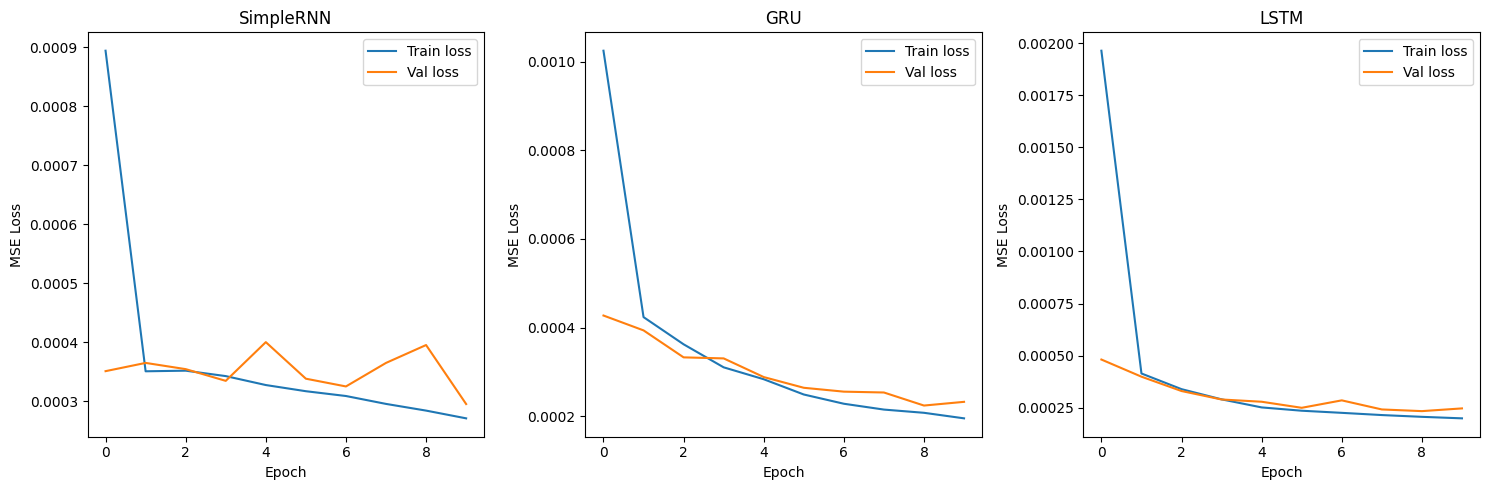

In [43]:
import matplotlib.pyplot as plt

# Completa l'exercici
EPOCHS = 10
BATCH_SIZE = 32

# --- Entrenament SimpleRNN ---
history_rnn = model_rnn.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# --- Entrenament GRU ---
history_gru = model_gru.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# --- Entrenament LSTM ---
history_lstm = model_lstm.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

# --- Visualització dels resultats ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_rnn.history['loss'], label='Train loss')
plt.plot(history_rnn.history['val_loss'], label='Val loss')
plt.title('SimpleRNN')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_gru.history['loss'], label='Train loss')
plt.plot(history_gru.history['val_loss'], label='Val loss')
plt.title('GRU')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_lstm.history['loss'], label='Train loss')
plt.plot(history_lstm.history['val_loss'], label='Val loss')
plt.title('LSTM')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 4.5. Fer Prediccions Futures i Comparar Rendiment

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong> Prediu valors futurs utilitzant el conjunt de prova i compara el rendiment.</p>
</div>




909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MSE SimpleRNN: 664440.20
MSE GRU      : 523150.80
MSE LSTM     : 554873.22


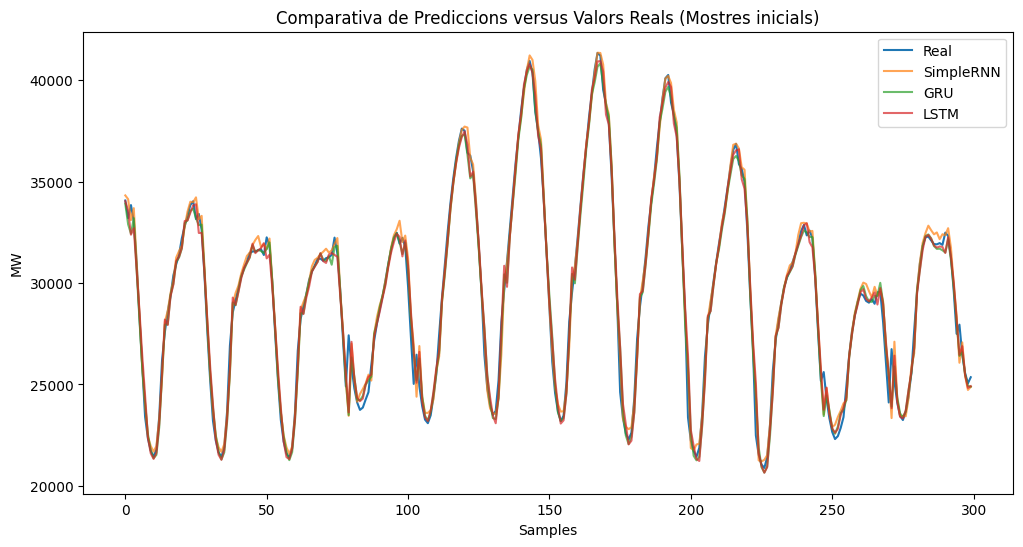

In [44]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Completa l'exercici
# Fem prediccions sobre el conjunt de validació
y_pred_rnn = model_rnn.predict(X_val_rnn)
y_pred_gru = model_gru.predict(X_val_rnn)
y_pred_lstm = model_lstm.predict(X_val_rnn)

# Desnormalitzem (per comparar amb els valors reals originals)
y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))
y_pred_rnn_inv = scaler.inverse_transform(y_pred_rnn)
y_pred_gru_inv = scaler.inverse_transform(y_pred_gru)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

# Avaluació: MSE real als valors originals
mse_rnn = mean_squared_error(y_val_inv, y_pred_rnn_inv)
mse_gru = mean_squared_error(y_val_inv, y_pred_gru_inv)
mse_lstm = mean_squared_error(y_val_inv, y_pred_lstm_inv)

print(f'MSE SimpleRNN: {mse_rnn:.2f}')
print(f'MSE GRU      : {mse_gru:.2f}')
print(f'MSE LSTM     : {mse_lstm:.2f}')

# Visualització:
plt.figure(figsize=(12, 6))
plt.plot(y_val_inv[:300], label='Real')
plt.plot(y_pred_rnn_inv[:300], label='SimpleRNN', alpha=0.7)
plt.plot(y_pred_gru_inv[:300], label='GRU', alpha=0.7)
plt.plot(y_pred_lstm_inv[:300], label='LSTM', alpha=0.7)
plt.title('Comparativa de Prediccions versus Valors Reals (Mostres inicials)')
plt.xlabel('Samples')
plt.ylabel('MW')
plt.legend()
plt.show()

Les corbes se superposen molt, cosa que indica que els models han aprés bé el patró general de la sèrie.

Revisant els MSE:

* MSE SimpleRNN: 664440.20
* MSE GRU      : 523150.80
* MSE LSTM     : 554873.22

El GRU és el model que millor ajustaa (error més baix), seguit molt de prop per LSTM.

SimpleRNN té un error força més gran, encara que tampoc és catastròfic.



## 4.6. Experimentar amb la Mida de Finestra

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong> Canvia el window_size per explorar com depèn la predicció de l'interval de temps. Prova per exemple amb una mida de finestra de 48 hores.</p>
</div>




Provarem tant amb la finestra de 24 i de 48 hores. Per això creo una funció que itera per les finestres.

Normalitzant la columna 'PJME_MW'...

*** FINESTRA TEMPORAL: 24 ***
Creant finestres desplaçades...
Dimensió X windows: (145342, 24)
Dimensió y windows: (145342,)
Separant entrenament/validació...
  X_train: (116273, 24) | X_val: (29069, 24)
Creant models...
-- SimpleRNN --


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Entrenament i avaluació...

Entrenant SimpleRNN...
Epoch 1/10
3634/3634 - 14s - 4ms/step - loss: 6.8220e-04 - val_loss: 3.8876e-04
Epoch 2/10
3634/3634 - 12s - 3ms/step - loss: 3.5240e-04 - val_loss: 3.7416e-04
Epoch 3/10
3634/3634 - 12s - 3ms/step - loss: 3.5552e-04 - val_loss: 3.6375e-04
Epoch 4/10
3634/3634 - 12s - 3ms/step - loss: 3.4020e-04 - val_loss: 3.5881e-04
Epoch 5/10
3634/3634 - 12s - 3ms/step - loss: 3.2662e-04 - val_loss: 3.9937e-04
Epoch 6/10
3634/3634 - 12s - 3ms/step - loss: 3.1690e-04 - val_loss: 3.4502e-04
Epoch 7/10
3634/3634 - 12s - 3ms/step - loss: 3.1500e-04 - val_loss: 3.5727e-04
Epoch 8/10
3634/3634 - 12s - 3ms/step - loss: 3.0571e-04 - val_loss: 3.2769e-04
Epoch 9/10
3634/3634 - 12s - 3ms/step - loss: 3.0052e-04 - val_loss: 3.2353e-04
Epoch 10/10
3634/3634 - 12s - 3ms/step - loss: 2.9516e-04 - val_loss: 3.0824e-04
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Entrenant GRU...
Epoch 1/10
3634/3634 - 14s - 4ms/step - loss: 0.0012 - val_loss: 4.1288e-04
Epoch 2/10
36

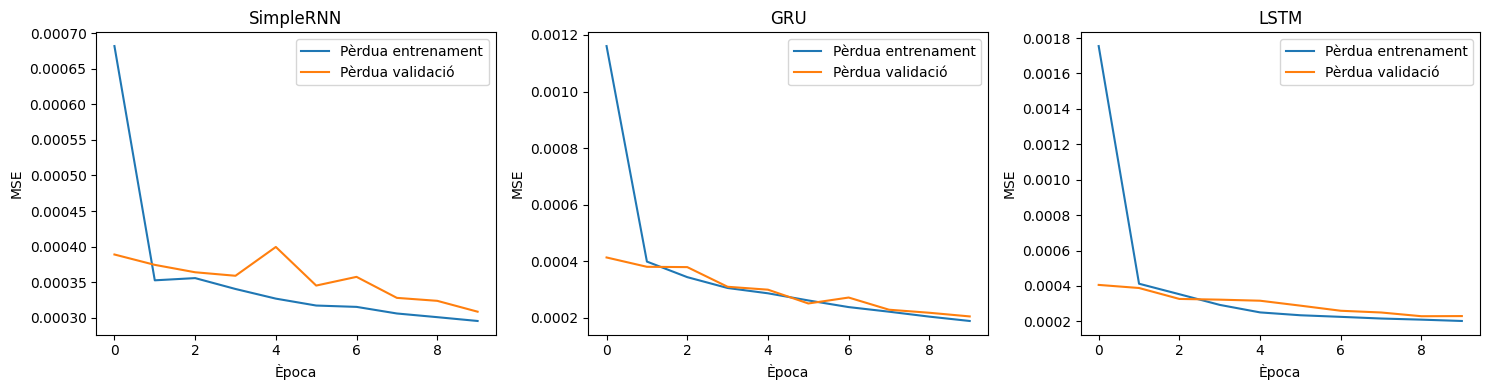

Gràfica de prediccions vs valors reals:


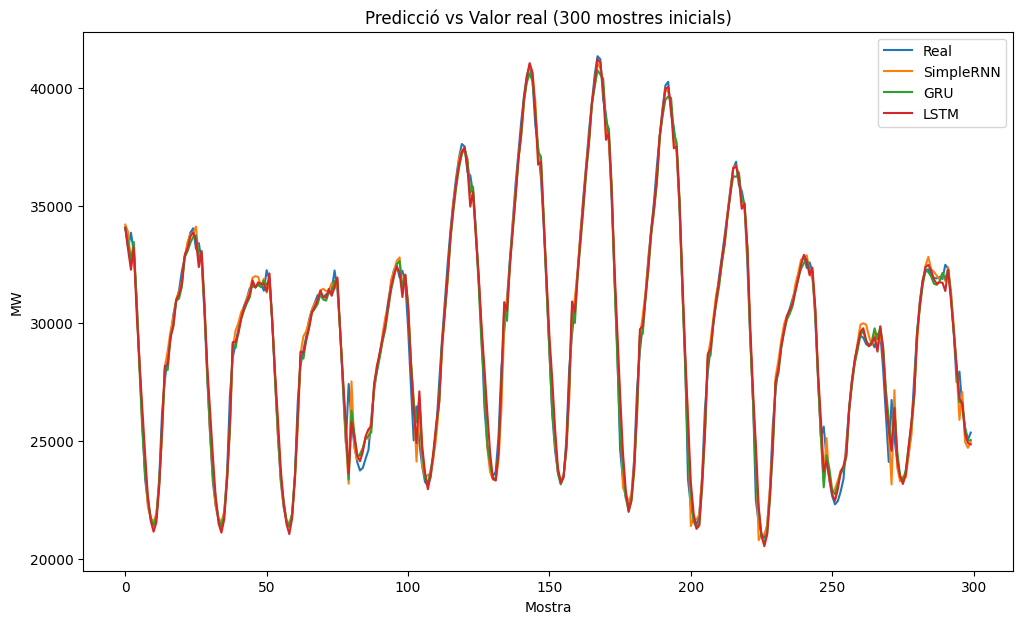


*** FINESTRA TEMPORAL: 48 ***
Creant finestres desplaçades...
Dimensió X windows: (145318, 48)
Dimensió y windows: (145318,)
Separant entrenament/validació...
  X_train: (116254, 48) | X_val: (29064, 48)
Creant models...
-- SimpleRNN --


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Entrenament i avaluació...

Entrenant SimpleRNN...
Epoch 1/10
3633/3633 - 21s - 6ms/step - loss: 6.3157e-04 - val_loss: 2.9534e-04
Epoch 2/10
3633/3633 - 19s - 5ms/step - loss: 2.5441e-04 - val_loss: 2.7157e-04
Epoch 3/10
3633/3633 - 18s - 5ms/step - loss: 2.5963e-04 - val_loss: 2.9444e-04
Epoch 4/10
3633/3633 - 19s - 5ms/step - loss: 2.6193e-04 - val_loss: 2.7890e-04
Epoch 5/10
3633/3633 - 18s - 5ms/step - loss: 2.5803e-04 - val_loss: 2.8990e-04
Epoch 6/10
3633/3633 - 19s - 5ms/step - loss: 2.5840e-04 - val_loss: 2.9978e-04
Epoch 7/10
3633/3633 - 18s - 5ms/step - loss: 2.5556e-04 - val_loss: 2.9140e-04
Epoch 8/10
3633/3633 - 19s - 5ms/step - loss: 2.5036e-04 - val_loss: 2.9631e-04
Epoch 9/10
3633/3633 - 19s - 5ms/step - loss: 2.4601e-04 - val_loss: 2.7139e-04
Epoch 10/10
3633/3633 - 18s - 5ms/step - loss: 2.4233e-04 - val_loss: 2.6314e-04
909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Entrenant GRU...
Epoch 1/10
3633/3633 - 17s - 5ms/step - loss: 0.0013 - val_loss: 4.8872e-04
Epoch 2/10
36

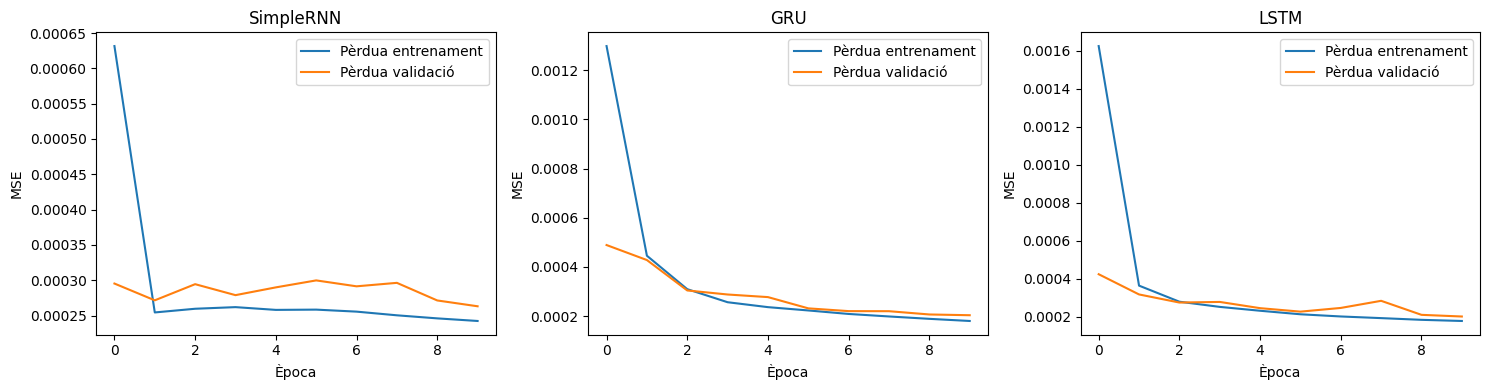

Gràfica de prediccions vs valors reals:


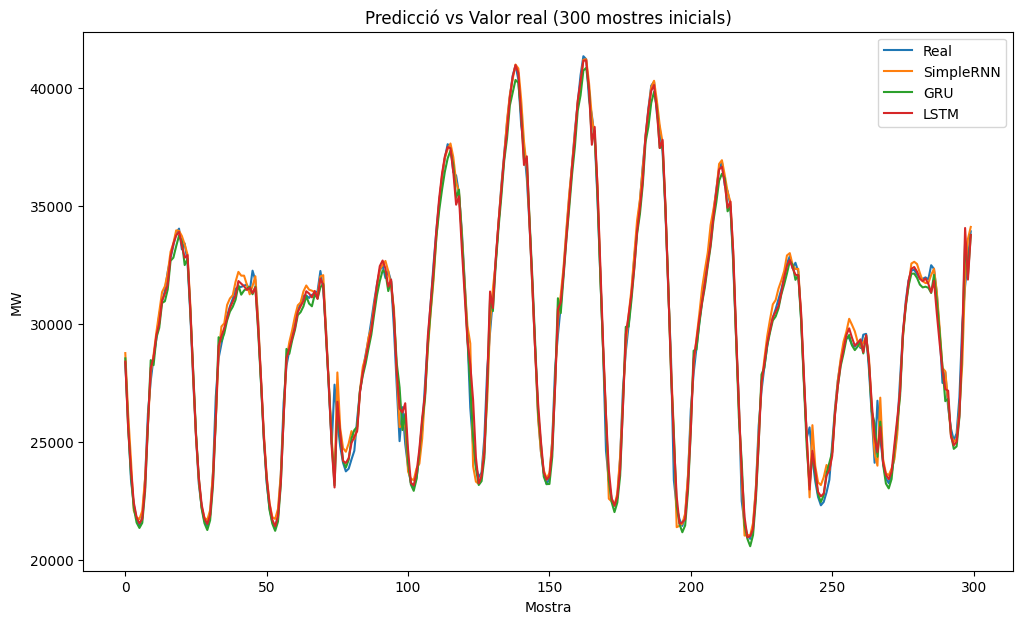

In [45]:
# Normalització de les dades (només un cop)
print("Normalitzant la columna 'PJME_MW'...")
values = df['PJME_MW'].values.reshape(-1, 1)
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# Funció per crear finestres (seqüències temporals)
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])
        y.append(data[i + window_size, 0])
    X = np.array(X)
    y = np.array(y)
    return X, y

# Funció per dividir en entrenament-validació
def prepare_train_val(X, y, split_ratio=0.8):
    split = int(split_ratio * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]
    return X_train, X_val, y_train, y_val

# Funció per crear els models RNN, GRU i LSTM
def build_models(window_size):
    models = {
        "SimpleRNN": Sequential([
            Input(shape=(window_size, 1)),
            SimpleRNN(50),
            Dense(1)
        ]),
        "GRU": Sequential([
            Input(shape=(window_size, 1)),
            GRU(50),
            Dense(1)
        ]),
        "LSTM": Sequential([
            Input(shape=(window_size, 1)),
            LSTM(50),
            Dense(1)
        ])
    }
    for model in models.values():
        model.compile(optimizer='adam', loss='mse')
    return models

# Entrenament i avaluació dels models
def train_and_evaluate(models, X_train, y_train, X_val, y_val, scaler, epochs=10, batch_size=32):
    histories = {}
    y_preds = {}
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1,1))
    mse_scores = {}
    for name, model in models.items():
        print(f"\nEntrenant {name}...")
        X_train_rnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_val_rnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
        histories[name] = model.fit(
            X_train_rnn, y_train,
            validation_data=(X_val_rnn, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=2
        )
        y_pred = model.predict(X_val_rnn)
        y_preds[name] = scaler.inverse_transform(y_pred)
        mse_scores[name] = mean_squared_error(y_val_inv, y_preds[name])
    return histories, y_preds, y_val_inv, mse_scores

# Gràfica de corbes d'aprenentatge
def plot_learning_curves(histories):
    plt.figure(figsize=(15, 4))
    for i, (name, history) in enumerate(histories.items()):
        plt.subplot(1, 3, i+1)
        plt.plot(history.history['loss'], label='Pèrdua entrenament')
        plt.plot(history.history['val_loss'], label='Pèrdua validació')
        plt.title(name)
        plt.xlabel('Època')
        plt.ylabel('MSE')
        plt.legend()
    plt.tight_layout()
    plt.show()

# Gràfica de resultats prediccions vs. valors reals
def plot_predictions(y_val_inv, y_preds, samples=300):
    plt.figure(figsize=(12,7))
    plt.plot(y_val_inv[:samples], label='Real')
    for name, preds in y_preds.items():
        plt.plot(preds[:samples], label=name)
    plt.title(f"Predicció vs Valor real ({samples} mostres inicials)")
    plt.xlabel('Mostra')
    plt.ylabel('MW')
    plt.legend()
    plt.show()

# Imprimir MSE dels models
def print_mse_scores(mse_scores):
    print("\nMSE sobre el conjunt de validació:")
    for name, mse in mse_scores.items():
        print(f"{name:10s}: {mse:.2f}")



for WINDOW_SIZE in [24, 48]:
    print("="*50)
    print(f"\n*** FINESTRA TEMPORAL: {WINDOW_SIZE} ***")
    print("="*50)
    print("Creant finestres desplaçades...")
    X, y = create_windows(values_scaled, WINDOW_SIZE)
    print(f"Dimensió X windows: {X.shape}")
    print(f"Dimensió y windows: {y.shape}")

    print("Separant entrenament/validació...")
    X_train, X_val, y_train, y_val = prepare_train_val(X, y)
    print("  X_train:", X_train.shape, "| X_val:", X_val.shape)

    print("Creant models...")
    models = build_models(WINDOW_SIZE)
    for name, m in models.items():
        print(f"-- {name} --")
        m.summary()

    print("Entrenament i avaluació...")
    histories, y_preds, y_val_inv, mse_scores = train_and_evaluate(
        models, X_train, y_train, X_val, y_val, scaler,
        epochs=10, batch_size=32
    )

    print_mse_scores(mse_scores)
    print("Corbes d'aprenentatge:")
    plot_learning_curves(histories)

    print("Gràfica de prediccions vs valors reals:")
    plot_predictions(y_val_inv, y_preds, samples=300)

GRU i LSTM funcionen millor que SimpleRNN (MSE de validació molt menor).

Per a finestra 48, els models van millor que amb finestra 24.

El loss i val_loss baixen i s'estabilitzen, senyal d'un entrenament correcte sense sobreajustament a simple vista.
En alguns models, la val_loss arriba a un mínim i després puja, semble que el model podria estar arribant al límit o necessitar early stopping per evitar sobreajustament.

## 4.7. Model LSTM Profund amb Optimització d'Hiperparàmetres utilitzant Optuna

Construir un model LSTM més profund (amb més capes) i utilitzar Optuna per optimitzar hiperparàmetres clau. A continuació, comparar el seu rendiment amb els models anteriors (RNN, GRU i LSTM bàsic)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1.75 pts.]:</strong> Definició del Model LSTM Profund. Crearem un model amb:

<ul>
 <li>2 capes LSTM (amb return_sequences=True a la primera per apilar-les).</li>
 <li>Capa Densa final.</li>
 <li>Dropout per a regularització (evitar overfitting).</li>
 </ul>

Després toca definir hiperparàmetres a Optimitzar amb Optuna. Optuna buscarà la millor combinació de:

 <ul>
  <li>Nombre de neurones a cada capa LSTM: Entre 32 i 128.</li>
  <li>Taxa de Dropout: Entre 0.1 i 0.5.</li>
  <li>Taxa d'aprenentatge (learning rate): Entre 1e-4 i 1e-2 (log scale).</li>
  <li>Batch size: 32, 64 o 128.</li>
 </ul>


 Finalment, avalua i compara amb els models anteriors. Per fer-ho et proporcionem el codi per a una millor llegibilitat.

 </p>

</div>





In [46]:
# !pip install optuna # Recorda instal·lar en cas de no tenir-lo
!pip install optuna
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
import optuna


In [47]:
# Completa l'exercici
window_size = 24  # Utilitzant les últimes 24 hores per predir la següent hora
X, y = [], []

for i in range(len(values_scaled) - window_size):
    X.append(values_scaled[i:i + window_size])
    y.append(values_scaled[i + window_size])

X, y = np.array(X), np.array(y)

split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape per als models recurrents
X_train_rnn = X_train.reshape((-1, window_size, 1))
X_test_rnn  = X_test.reshape((-1, window_size, 1))

# Model optuna
def create_lstm_model(trial, window_size):
    n_units_1 = trial.suggest_int('n_units_lstm1', 32, 128)
    n_units_2 = trial.suggest_int('n_units_lstm2', 32, 128)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(n_units_1, return_sequences=True),
        Dropout(dropout),
        LSTM(n_units_2),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

def objective(trial):
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    model = create_lstm_model(trial, window_size)
    history = model.fit(
        X_train_rnn, y_train,
        validation_split=0.15, 
        epochs=7,             
        batch_size=batch_size,
        verbose=0
    )
    return min(history.history['val_loss'])


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print("Millors hiperparàmetres:", study.best_trial.params)

# Entrena el millor model amb aquests hiperparàmetres
best_params = study.best_trial.params
model_deep_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(best_params['n_units_lstm1'], return_sequences=True),
    Dropout(best_params['dropout']),
    LSTM(best_params['n_units_lstm2']),
    Dropout(best_params['dropout']),
    Dense(1)
])
model_deep_lstm.compile(
    optimizer=Adam(learning_rate=best_params['lr']),
    loss='mse'
)
history = model_deep_lstm.fit(
    X_train_rnn, y_train,
    validation_data=(X_test_rnn, y_test),
    epochs=20,
    batch_size=best_params['batch_size'],
    verbose=2
)

[I 2025-04-22 20:24:38,092] A new study created in memory with name: no-name-416893a5-b93a-476d-a6f7-4d72816056b4
[I 2025-04-22 20:26:47,088] Trial 0 finished with value: 0.0003382716968189925 and parameters: {'batch_size': 32, 'n_units_lstm1': 111, 'n_units_lstm2': 40, 'dropout': 0.39017809470014875, 'lr': 0.0002995660248755071}. Best is trial 0 with value: 0.0003382716968189925.
[I 2025-04-22 20:27:25,097] Trial 1 finished with value: 0.00037684437120333314 and parameters: {'batch_size': 128, 'n_units_lstm1': 116, 'n_units_lstm2': 125, 'dropout': 0.16096469629455426, 'lr': 0.0004132444893981696}. Best is trial 0 with value: 0.0003382716968189925.
[I 2025-04-22 20:29:31,173] Trial 2 finished with value: 0.0002086252352455631 and parameters: {'batch_size': 32, 'n_units_lstm1': 55, 'n_units_lstm2': 78, 'dropout': 0.1550538665917404, 'lr': 0.003644205593251006}. Best is trial 2 with value: 0.0002086252352455631.
[I 2025-04-22 20:31:37,779] Trial 3 finished with value: 0.00031334755476564

Millors hiperparàmetres: {'batch_size': 32, 'n_units_lstm1': 58, 'n_units_lstm2': 70, 'dropout': 0.10735601042114856, 'lr': 0.003670794018841867}
Epoch 1/20
3634/3634 - 24s - 7ms/step - loss: 0.0012 - val_loss: 3.8141e-04
Epoch 2/20
3634/3634 - 22s - 6ms/step - loss: 4.5234e-04 - val_loss: 3.1166e-04
Epoch 3/20
3634/3634 - 22s - 6ms/step - loss: 3.7283e-04 - val_loss: 2.8529e-04
Epoch 4/20
3634/3634 - 22s - 6ms/step - loss: 3.2972e-04 - val_loss: 2.6614e-04
Epoch 5/20
3634/3634 - 22s - 6ms/step - loss: 3.0474e-04 - val_loss: 2.3583e-04
Epoch 6/20
3634/3634 - 22s - 6ms/step - loss: 2.8253e-04 - val_loss: 2.4484e-04
Epoch 7/20
3634/3634 - 22s - 6ms/step - loss: 2.7424e-04 - val_loss: 2.2143e-04
Epoch 8/20
3634/3634 - 22s - 6ms/step - loss: 2.5813e-04 - val_loss: 2.4126e-04
Epoch 9/20
3634/3634 - 22s - 6ms/step - loss: 2.4979e-04 - val_loss: 2.3795e-04
Epoch 10/20
3634/3634 - 22s - 6ms/step - loss: 2.4061e-04 - val_loss: 2.0301e-04
Epoch 11/20
3634/3634 - 22s - 6ms/step - loss: 2.3509e-04

909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MSE (Deep LSTM + Optuna): 0.000172
Comparació de MSE:
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
- RNN: 0.000295
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
- GRU: 0.000232
909/909 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
- LSTM bàsic: 0.000246
- LSTM profund + Optuna: 0.000172
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


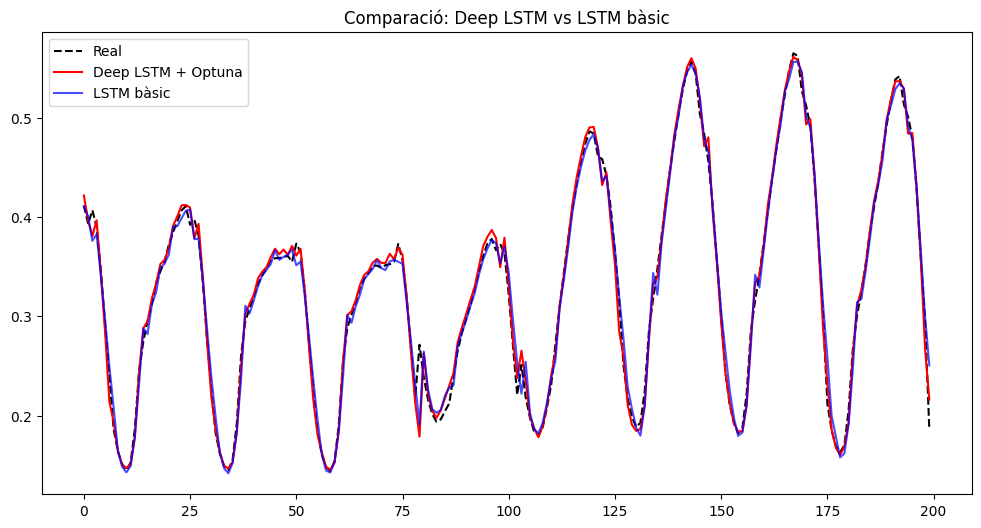

In [48]:
from sklearn.metrics import mean_squared_error

# Avaluar el model profund
deep_lstm_mse = mean_squared_error(y_test, model_deep_lstm.predict(X_test))
print(f"MSE (Deep LSTM + Optuna): {deep_lstm_mse:.6f}")

# Comparar amb models anteriors (exercici 5)
print("Comparació de MSE:")
print(f"- RNN: {mean_squared_error(y_test, model_rnn.predict(X_test)):.6f}")
print(f"- GRU: {mean_squared_error(y_test, model_gru.predict(X_test)):.6f}")
print(f"- LSTM bàsic: {mean_squared_error(y_test, model_lstm.predict(X_test)):.6f}")
print(f"- LSTM profund + Optuna: {deep_lstm_mse:.6f}")

# Gràfica comparativa de prediccions (primeres 200 mostres)
plt.figure(figsize=(12, 6))
plt.plot(y_test[:200], label='Real', color='black', linestyle='--')
plt.plot(model_deep_lstm.predict(X_test[:200]), label='Deep LSTM + Optuna', color='red')
plt.plot(model_lstm.predict(X_test[:200]), label='LSTM bàsic', color='blue', alpha=0.7)
plt.legend()
plt.title("Comparació: Deep LSTM vs LSTM bàsic")
plt.show()

Deep LSTM + Optuna obté el millor resultat seguit de GRU.

Iterar els hiperparàmetres de LSTM millora l'ajust del model al trobar valors més òptims d'entrenament.

Visualment, tots dos models (LSTM bàsic i Deep LSTM + Optuna) capturen molt bé la dinàmica de la sèrie.

La diferència principal entre LSTM bàsic i “Deep LSTM + Optuna” es veu pics i valls, on el deep LSTM + Optuna ajusta millor.